<a href="https://colab.research.google.com/github/jumafernandez/ANN-UNSL/blob/main/notebooks/version_4/notebook_03_ema_dialog2flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03 — Estados EMA Dialog2Flow 2.0

Esta notebook construye variantes acumulativas con **Exponentially Moving Average (EMA)** a partir de los embeddings `dialog2flow-joint-bert-base`.

La motivación es comparar la acumulación uniforme usada previamente con una política que controle explícitamente el peso relativo entre el turno actual y el historial conversacional.

La actualización evaluada es:

```text
h_t = LayerNorm((1 - alpha) * h_{t-1} + alpha * e_t)
```

donde `e_t` es el embedding estático del turno actual, `h_{t-1}` es el estado acumulado previo y `alpha` regula cuánto pesa el turno actual frente al historial.

In [1]:
!pip install -q gdown faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 53.6 MB/s eta 0:00:00


## 1. Configuración del experimento

En esta versión se trabaja únicamente con `dialog2flow-joint-bert-base`, porque fue el espacio donde la representación acumulativa mostró el comportamiento más interesante en el paper.

Se evalúa una grilla de valores de `alpha` entre 0.1 y 0.9. Valores bajos preservan más historial, mientras que valores altos dan mayor peso al turno actual.

In [2]:
EMBEDDING_EXPERIMENTO = "dialog2flow-joint-bert-base"

RANDOM_STATE = 42

# Cantidad de consultas para comparar vecindades exactas.
N_QUERIES = 10000

# Vecinos máximos para evaluar Overlap@1, Overlap@10 y Overlap@100.
K_MAX = 100

# Tamaño de muestra para gráficos exploratorios.
N_MUESTRA_ANALISIS = 100000

# Valores de alpha sugeridos para explorar cuánto historial conviene codificar.
ALPHA_VALUES = [round(x / 10, 1) for x in range(1, 10)]

# Carpeta de salida versionada.
VERSION = "version_4"

print("Experimento:", EMBEDDING_EXPERIMENTO)
print("Alphas:", ALPHA_VALUES)
print("Versión:", VERSION)

Experimento: dialog2flow-joint-bert-base
Alphas: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Versión: version_4


## 2. Archivos de entrada

Usamos los mismos insumos de las notebooks anteriores:

- `dialogs-2.0.pkl`: dataframe con turnos y metadatos conversacionales.
- `ids.npy`: identificadores de filas.
- `embeddings_dialog2flow.npy`: embeddings estáticos del modelo Dialog2Flow.

La notebook conserva el mecanismo de descarga por Google Drive usado en la versión anterior. Si los archivos ya existen localmente, no se vuelven a descargar.

In [3]:
# Ids de Google Drive usados en las notebooks previas.

id_ids = "1hWC7nLvSboFHyykjr7VFAEmcvz8re1cY"
id_embeddings_dialog2flow = "1Pxf6oho0HYwv3B8VObZ_R6asShyK1WFW"
id_dataset = "1kRbmvg3NB96pWMUl866GZRrT6Zq9vxcb"

archivo_embeddings = "embeddings_dialog2flow.npy"
short_name = "dialog2flow"

## 3. Descarga y carga de datos

Los embeddings se cargan con `mmap_mode="r"` para evitar cargar toda la matriz en memoria de forma innecesaria.

In [4]:
import os
import gc
import time
import json
import shutil
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss
import torch

from datetime import datetime
from zoneinfo import ZoneInfo

archivos = {
    archivo_embeddings: id_embeddings_dialog2flow,
    "ids.npy": id_ids,
    "dialogs-2.0.pkl": id_dataset,
}

for nombre_archivo, file_id in archivos.items():
    if not os.path.exists(nombre_archivo):
        print("Descargando:", nombre_archivo)
        gdown.download(f"https://drive.google.com/uc?id={file_id}", nombre_archivo, quiet=False)
    else:
        print("Ya existe:", nombre_archivo)

print("Experimento:", EMBEDDING_EXPERIMENTO)
print("Archivo de embeddings:", archivo_embeddings)
print("Nombre corto:", short_name)

Descargando: embeddings_dialog2flow.npy


Downloading...
From (original): https://drive.google.com/uc?id=1Pxf6oho0HYwv3B8VObZ_R6asShyK1WFW
From (redirected): https://drive.google.com/uc?id=1Pxf6oho0HYwv3B8VObZ_R6asShyK1WFW&confirm=t&uuid=afdedfa8-ec5f-4356-aeda-842903a135b2
To: /content/embeddings_dialog2flow.npy
100%|██████████| 3.07G/3.07G [08:16<00:00, 6.19MB/s]


Descargando: ids.npy


Downloading...
From: https://drive.google.com/uc?id=1hWC7nLvSboFHyykjr7VFAEmcvz8re1cY
To: /content/ids.npy
100%|██████████| 8.00M/8.00M [00:00<00:00, 182MB/s]


Descargando: dialogs-2.0.pkl


Downloading...
From (original): https://drive.google.com/uc?id=1kRbmvg3NB96pWMUl866GZRrT6Zq9vxcb
From (redirected): https://drive.google.com/uc?id=1kRbmvg3NB96pWMUl866GZRrT6Zq9vxcb&confirm=t&uuid=042b217f-72eb-4ec7-a0e1-1dce133571fe
To: /content/dialogs-2.0.pkl
100%|██████████| 156M/156M [00:00<00:00, 170MB/s]

Experimento: dialog2flow-joint-bert-base
Archivo de embeddings: embeddings_dialog2flow.npy
Nombre corto: dialog2flow


In [5]:
embeddings = np.load(archivo_embeddings, mmap_mode="r")
ids = np.load("ids.npy")
df = pd.read_pickle("dialogs-2.0.pkl")

print("Embeddings:", embeddings.shape, embeddings.dtype)
print("Ids:", ids.shape)
print("Dataset:", df.shape)

df.head()

Embeddings: (1000023, 768) float32
Ids: (1000023,)
Dataset: (1000023, 11)


,dataset,split,dialogue_id,turn_id,speaker,utterance,domains,dialog_acts,main_acts,slots,intents
0,ABCD,test,ABCD_test_0,0,user,Hi. My name is Chloe Zhang. I am curious as ...,[storewide query],None,None,None,[timing]
1,ABCD,test,ABCD_test_1,0,user,Hello. I recently signed up for a subscription...,[subscription inquiry],None,None,None,[manage dispute bill]
2,ABCD,test,ABCD_test_1,1,user,"sure, it's Albert Sanders and my account id is...",[subscription inquiry],None,None,[account id],None
3,ABCD,test,ABCD_test_1,2,user,yes its 7149958247,[subscription inquiry],None,None,[order id],None
4,ABCD,test,ABCD_test_2,0,user,I'm thinking about buying an item but first i ...,[single item query],None,None,None,[shirt]


## 4. Construcción de representaciones EMA

Para cada valor de `alpha`, se recorre cada diálogo en orden conversacional y se reinicia el estado acumulado al comienzo de la conversación.

A diferencia de la acumulación uniforme:

```text
h_t = LayerNorm(h_{t-1} + e_t)
```

la variante EMA pondera explícitamente el turno actual y el historial:

```text
h_t = LayerNorm((1 - alpha) * h_{t-1} + alpha * e_t)
```

Esto permite estudiar si conviene preservar más historia o enfatizar más el turno actual.

In [6]:
def cosine_np(a, b, eps=1e-12):
    return float(np.dot(a, b) / ((np.linalg.norm(a) + eps) * (np.linalg.norm(b) + eps)))


def alpha_tag(alpha):
    return f"{alpha:.1f}".replace(".", "_")


def archivo_ema(alpha):
    return f"ema_embeddings_{short_name}_alpha_{alpha_tag(alpha)}.npy"


def archivo_similitud_ema(alpha):
    return f"similitud_static_ema_{short_name}_alpha_{alpha_tag(alpha)}.npy"


def archivo_turn_pos_ema(alpha):
    return f"turn_position_ema_{short_name}_alpha_{alpha_tag(alpha)}.npy"

In [7]:
n, d = embeddings.shape

# LayerNorm se define una sola vez usando la dimensionalidad de los embeddings.
# Se usa en CPU para conservar el estilo de la notebook anterior.
layer_norm = torch.nn.LayerNorm(d, elementwise_affine=False)
layer_norm.eval()

print("Cantidad de vectores:", n)
print("Dimensión:", d)

Cantidad de vectores: 1000023
Dimensión: 768


In [8]:
archivos_generados = []

for alpha in ALPHA_VALUES:
    archivo_dynamic = archivo_ema(alpha)
    archivo_similitud = archivo_similitud_ema(alpha)
    archivo_turn_pos = archivo_turn_pos_ema(alpha)

    if os.path.exists(archivo_dynamic) and os.path.exists(archivo_similitud) and os.path.exists(archivo_turn_pos):
        print(f"Alpha={alpha}: archivos ya existentes. Se omite generación.")
        archivos_generados.append((alpha, archivo_dynamic, archivo_similitud, archivo_turn_pos))
        continue

    print("=" * 100)
    print(f"Generando EMA para alpha={alpha}")
    print("Archivo de salida:", archivo_dynamic)

    ema_embeddings = np.lib.format.open_memmap(
        archivo_dynamic,
        mode="w+",
        dtype="float32",
        shape=(n, d)
    )

    similitud_static_ema = np.lib.format.open_memmap(
        archivo_similitud,
        mode="w+",
        dtype="float32",
        shape=(n,)
    )

    turn_position = np.lib.format.open_memmap(
        archivo_turn_pos,
        mode="w+",
        dtype="int32",
        shape=(n,)
    )

    t0 = time.time()
    cantidad_dialogos = 0

    with torch.no_grad():
        for dialogue_id, grupo in df.groupby("dialogue_id", sort=False):
            grupo = grupo.sort_values("turn_id")
            indices_dialogo = grupo.index.to_numpy()

            h = torch.zeros(d, dtype=torch.float32)

            for idx in indices_dialogo:
                e_np = np.asarray(embeddings[idx], dtype="float32")
                e = torch.from_numpy(e_np.copy())

                h = layer_norm((1.0 - alpha) * h + alpha * e)
                h_np = h.numpy().astype("float32", copy=False)

                ema_embeddings[idx] = h_np
                similitud_static_ema[idx] = cosine_np(e_np, h_np)
                turn_position[idx] = int(df.loc[idx, "turn_id"])

            cantidad_dialogos += 1

            if cantidad_dialogos % 10000 == 0:
                print("Diálogos procesados:", cantidad_dialogos)

    ema_embeddings.flush()
    similitud_static_ema.flush()
    turn_position.flush()

    print(f"EMA alpha={alpha} generada en {time.time() - t0:.2f} segundos.")

    archivos_generados.append((alpha, archivo_dynamic, archivo_similitud, archivo_turn_pos))

print("Cantidad de variantes EMA generadas:", len(archivos_generados))

Generando EMA para alpha=0.1
Archivo de salida: ema_embeddings_dialog2flow_alpha_0_1.npy
Diálogos procesados: 10000
Diálogos procesados: 20000
Diálogos procesados: 30000
Diálogos procesados: 40000
Diálogos procesados: 50000
Diálogos procesados: 60000
Diálogos procesados: 70000
Diálogos procesados: 80000
Diálogos procesados: 90000
Diálogos procesados: 100000
EMA alpha=0.1 generada en 244.45 segundos.
Generando EMA para alpha=0.2
Archivo de salida: ema_embeddings_dialog2flow_alpha_0_2.npy
Diálogos procesados: 10000
Diálogos procesados: 20000
Diálogos procesados: 30000
Diálogos procesados: 40000
Diálogos procesados: 50000
Diálogos procesados: 60000
Diálogos procesados: 70000
Diálogos procesados: 80000
Diálogos procesados: 90000
Diálogos procesados: 100000
EMA alpha=0.2 generada en 201.02 segundos.
Generando EMA para alpha=0.3
Archivo de salida: ema_embeddings_dialog2flow_alpha_0_3.npy
Diálogos procesados: 10000
Diálogos procesados: 20000
Diálogos procesados: 30000
Diálogos procesados: 400

## 5. Análisis base vs EMA

Se calcula la similitud coseno entre cada embedding estático `e_t` y su correspondiente estado EMA `h_t`.

Esta métrica permite observar cuánto se aleja cada variante EMA del embedding individual de turno a medida que cambia `alpha`.

In [9]:
np.random.seed(RANDOM_STATE)

muestra_size = min(N_MUESTRA_ANALISIS, embeddings.shape[0])
muestra_idx = np.random.choice(embeddings.shape[0], size=muestra_size, replace=False)

resumen_similitud = []

for alpha, archivo_dynamic, archivo_similitud, archivo_turn_pos in archivos_generados:
    similitud_static_ema = np.load(archivo_similitud, mmap_mode="r")
    turn_position = np.load(archivo_turn_pos, mmap_mode="r")

    sim_muestra = np.asarray(similitud_static_ema[muestra_idx])
    turn_muestra = np.asarray(turn_position[muestra_idx])

    resumen_similitud.append({
        "alpha": alpha,
        "similarity_mean": float(sim_muestra.mean()),
        "similarity_median": float(np.median(sim_muestra)),
        "similarity_min": float(sim_muestra.min()),
        "similarity_max": float(sim_muestra.max()),
        "turn_position_mean": float(turn_muestra.mean()),
        "turn_position_median": float(np.median(turn_muestra)),
    })

df_resumen_similitud = pd.DataFrame(resumen_similitud)
df_resumen_similitud

,alpha,similarity_mean,similarity_median,similarity_min,similarity_max,turn_position_mean,turn_position_median
0,0.1,0.455282,0.390619,0.089299,0.999714,7.12549,5.0
1,0.2,0.529905,0.480522,0.146261,0.999714,7.12549,5.0
2,0.3,0.597628,0.559024,0.217387,0.999714,7.12549,5.0
3,0.4,0.662203,0.631605,0.306966,0.999714,7.12549,5.0
4,0.5,0.726863,0.702412,0.416406,0.999714,7.12549,5.0
5,0.6,0.793568,0.774563,0.539302,0.999714,7.12549,5.0
6,0.7,0.862080,0.849532,0.686522,0.999714,7.12549,5.0
7,0.8,0.927887,0.922057,0.820903,0.999714,7.12549,5.0
8,0.9,0.979353,0.978148,0.946931,0.999714,7.12549,5.0


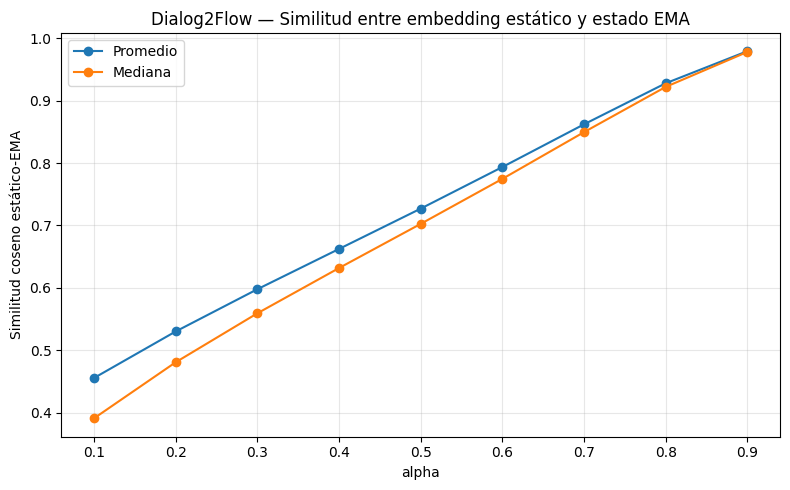

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(df_resumen_similitud["alpha"], df_resumen_similitud["similarity_mean"], marker="o", label="Promedio")
plt.plot(df_resumen_similitud["alpha"], df_resumen_similitud["similarity_median"], marker="o", label="Mediana")
plt.xlabel("alpha")
plt.ylabel("Similitud coseno estático-EMA")
plt.title("Dialog2Flow — Similitud entre embedding estático y estado EMA")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Evolución de la similitud por posición de turno

Además del promedio global, interesa observar cómo cambia la similitud estático-EMA a lo largo del diálogo. Esto ayuda a interpretar si algunos valores de `alpha` preservan más historial en turnos avanzados.

In [11]:
df_turn_all = []

for alpha, archivo_dynamic, archivo_similitud, archivo_turn_pos in archivos_generados:
    similitud_static_ema = np.load(archivo_similitud, mmap_mode="r")
    turn_position = np.load(archivo_turn_pos, mmap_mode="r")

    sim_muestra = np.asarray(similitud_static_ema[muestra_idx])
    turn_muestra = np.asarray(turn_position[muestra_idx])

    df_tmp = pd.DataFrame({
        "alpha": alpha,
        "turn_position": turn_muestra,
        "similarity": sim_muestra
    })

    df_turn_all.append(df_tmp)

df_turn_all = pd.concat(df_turn_all, ignore_index=True)

df_turn = (
    df_turn_all[df_turn_all["turn_position"] <= 30]
    .groupby(["alpha", "turn_position"], as_index=False)
    .agg(
        similarity_mean=("similarity", "mean"),
        similarity_median=("similarity", "median")
    )
)

df_turn.head()

,alpha,turn_position,similarity_mean,similarity_median
0,0.1,0,0.999511,0.999515
1,0.1,1,0.396500,0.362650
2,0.1,2,0.405568,0.379149
3,0.1,3,0.389516,0.363194
4,0.1,4,0.387398,0.364866


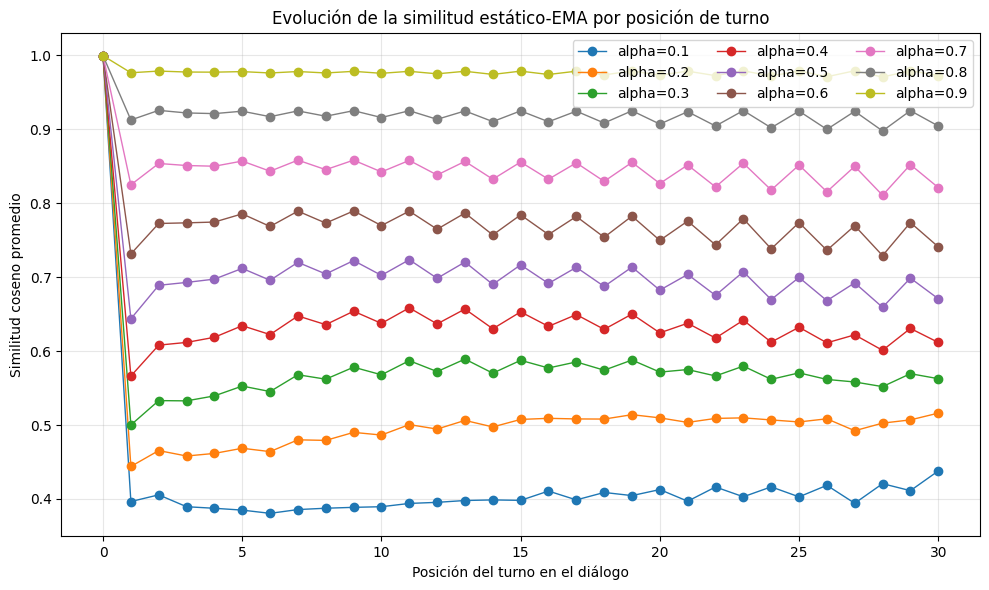

In [12]:
plt.figure(figsize=(10, 6))

for alpha in ALPHA_VALUES:
    subset = df_turn[df_turn["alpha"] == alpha]
    plt.plot(
        subset["turn_position"],
        subset["similarity_mean"],
        marker="o",
        linewidth=1,
        label=f"alpha={alpha}"
    )

plt.xlabel("Posición del turno en el diálogo")
plt.ylabel("Similitud coseno promedio")
plt.title("Evolución de la similitud estático-EMA por posición de turno")
plt.legend(ncol=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Superposición de vecindades exactas

Se compara la vecindad exacta inducida por los embeddings estáticos con la vecindad exacta inducida por cada variante EMA.

Esta comparación permite estimar cuánto cambia la estructura local del espacio al variar `alpha`.

In [13]:
def recall_at_k(I_exact, I_test, k):
    recalls = []

    for exact, test in zip(I_exact[:, :k], I_test[:, :k]):
        recalls.append(len(set(exact).intersection(set(test))) / k)

    return float(np.mean(recalls))


def preparar_split(n_total, n_queries, random_state):
    np.random.seed(random_state)

    query_idx = np.random.choice(
        n_total,
        size=n_queries,
        replace=False
    )

    mask = np.ones(n_total, dtype=bool)
    mask[query_idx] = False
    index_idx = np.where(mask)[0]

    return index_idx, query_idx


def obtener_vecinos_flat(matriz, index_idx, query_idx, k):
    index_vectors = np.asarray(matriz[index_idx], dtype="float32")
    query_vectors = np.asarray(matriz[query_idx], dtype="float32")

    faiss.normalize_L2(index_vectors)
    faiss.normalize_L2(query_vectors)

    d = index_vectors.shape[1]

    index_flat = faiss.IndexFlatL2(d)
    index_flat.add(index_vectors)

    D, I = index_flat.search(query_vectors, k)

    del index_flat
    del D
    del index_vectors
    del query_vectors
    gc.collect()

    return I

In [14]:
index_idx, query_idx = preparar_split(
    n_total=embeddings.shape[0],
    n_queries=N_QUERIES,
    random_state=RANDOM_STATE
)

print("Vectores indexados:", index_idx.shape)
print("Vectores de consulta:", query_idx.shape)

Vectores indexados: (990023,)
Vectores de consulta: (10000,)


In [15]:
print("Calculando vecinos exactos de embeddings estáticos...")
I_static_exact = obtener_vecinos_flat(embeddings, index_idx, query_idx, K_MAX)

resumen_overlap = []

for alpha, archivo_dynamic, archivo_similitud, archivo_turn_pos in archivos_generados:
    print("=" * 100)
    print("Calculando vecinos exactos EMA alpha=", alpha)

    ema_embeddings = np.load(archivo_dynamic, mmap_mode="r")
    I_ema_exact = obtener_vecinos_flat(ema_embeddings, index_idx, query_idx, K_MAX)

    overlap_1 = recall_at_k(I_static_exact, I_ema_exact, 1)
    overlap_10 = recall_at_k(I_static_exact, I_ema_exact, 10)
    overlap_100 = recall_at_k(I_static_exact, I_ema_exact, 100)

    resumen_overlap.append({
        "alpha": alpha,
        "overlap@1": overlap_1,
        "overlap@10": overlap_10,
        "overlap@100": overlap_100,
    })

    print("Overlap@1:", overlap_1)
    print("Overlap@10:", overlap_10)
    print("Overlap@100:", overlap_100)

    del ema_embeddings
    del I_ema_exact
    gc.collect()

df_resumen_overlap = pd.DataFrame(resumen_overlap)
df_resumen_overlap

Calculando vecinos exactos de embeddings estáticos...
Calculando vecinos exactos EMA alpha= 0.1
Overlap@1: 0.2382
Overlap@10: 0.09469
Overlap@100: 0.033767
Calculando vecinos exactos EMA alpha= 0.2
Overlap@1: 0.248
Overlap@10: 0.10087
Overlap@100: 0.045398
Calculando vecinos exactos EMA alpha= 0.3
Overlap@1: 0.2559
Overlap@10: 0.11515
Overlap@100: 0.066391
Calculando vecinos exactos EMA alpha= 0.4
Overlap@1: 0.274
Overlap@10: 0.14065999999999998
Overlap@100: 0.100576
Calculando vecinos exactos EMA alpha= 0.5
Overlap@1: 0.2978
Overlap@10: 0.17489000000000002
Overlap@100: 0.15154499999999999
Calculando vecinos exactos EMA alpha= 0.6
Overlap@1: 0.3304
Overlap@10: 0.22311999999999999
Overlap@100: 0.22591999999999998
Calculando vecinos exactos EMA alpha= 0.7
Overlap@1: 0.377
Overlap@10: 0.30029
Overlap@100: 0.33965200000000006
Calculando vecinos exactos EMA alpha= 0.8
Overlap@1: 0.4453
Overlap@10: 0.43383
Overlap@100: 0.524381
Calculando vecinos exactos EMA alpha= 0.9
Overlap@1: 0.5458
Over

,alpha,overlap@1,overlap@10,overlap@100
0,0.1,0.2382,0.09469,0.033767
1,0.2,0.2480,0.10087,0.045398
2,0.3,0.2559,0.11515,0.066391
3,0.4,0.2740,0.14066,0.100576
4,0.5,0.2978,0.17489,0.151545
5,0.6,0.3304,0.22312,0.225920
6,0.7,0.3770,0.30029,0.339652
7,0.8,0.4453,0.43383,0.524381
8,0.9,0.5458,0.65343,0.764803


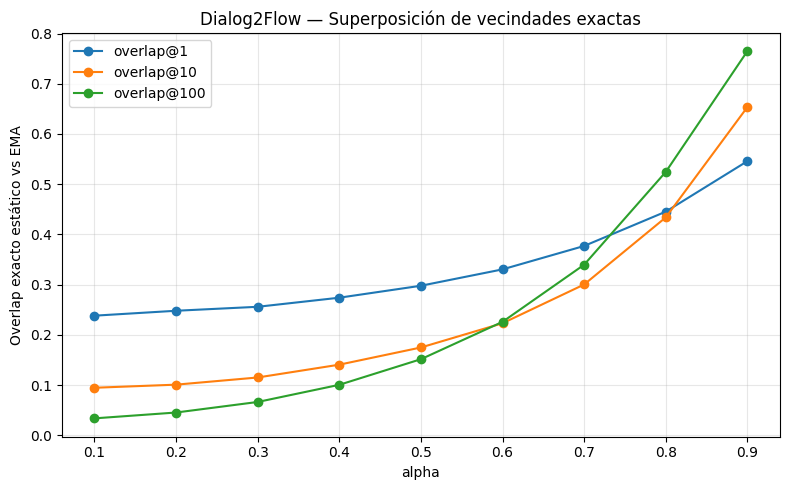

In [16]:
plt.figure(figsize=(8, 5))

for metric in ["overlap@1", "overlap@10", "overlap@100"]:
    plt.plot(df_resumen_overlap["alpha"], df_resumen_overlap[metric], marker="o", label=metric)

plt.xlabel("alpha")
plt.ylabel("Overlap exacto estático vs EMA")
plt.title("Dialog2Flow — Superposición de vecindades exactas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Visualización UMAP exploratoria

Se proyecta una muestra de embeddings estáticos y variantes EMA para observar visualmente cómo cambia la organización del espacio al variar `alpha`.

Para no sobrecargar el gráfico, se muestran algunos valores representativos de `alpha`.

In [17]:
!pip install -q umap-learn

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


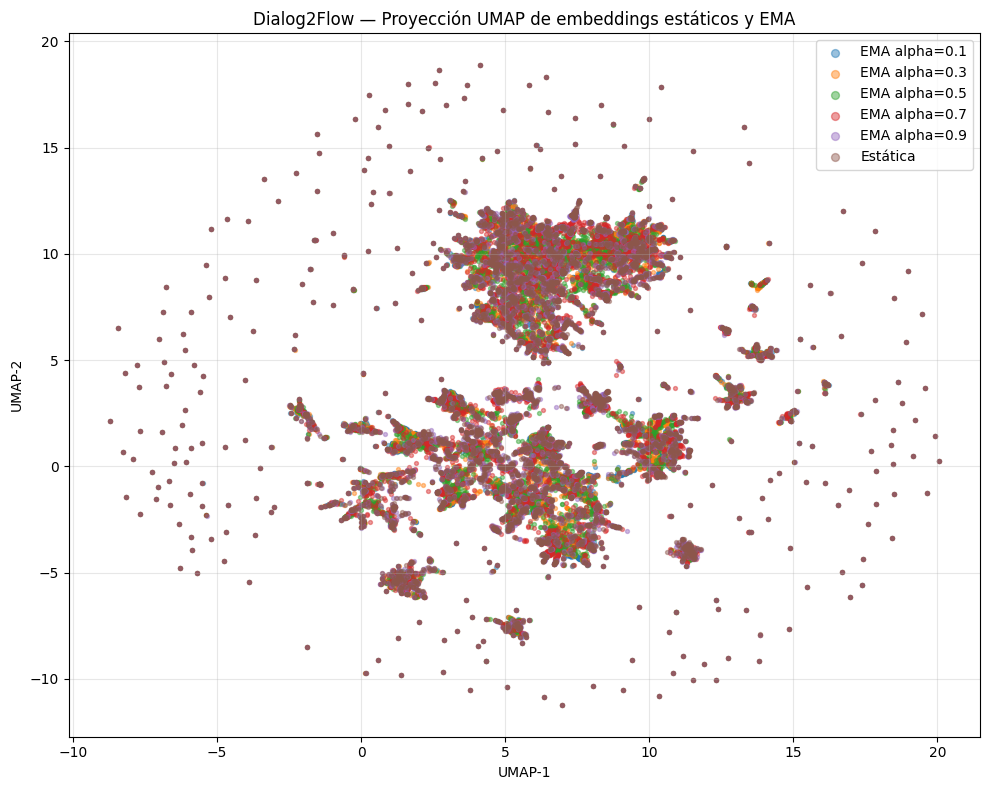

In [18]:
import umap

N_UMAP = 5000
RANDOM_STATE_UMAP = 42
ALPHAS_UMAP = [0.1, 0.3, 0.5, 0.7, 0.9]

np.random.seed(RANDOM_STATE_UMAP)

umap_idx = np.random.choice(
    np.arange(embeddings.shape[0]),
    size=min(N_UMAP, embeddings.shape[0]),
    replace=False
)

matrices_umap = []
labels_umap = []

static_umap = np.asarray(embeddings[umap_idx], dtype="float32")
matrices_umap.append(static_umap)
labels_umap.extend(["Estática"] * len(static_umap))

for alpha, archivo_dynamic, _, _ in archivos_generados:
    if alpha not in ALPHAS_UMAP:
        continue

    ema_embeddings = np.load(archivo_dynamic, mmap_mode="r")
    ema_umap = np.asarray(ema_embeddings[umap_idx], dtype="float32")

    matrices_umap.append(ema_umap)
    labels_umap.extend([f"EMA alpha={alpha}"] * len(ema_umap))

X_umap = np.vstack(matrices_umap)
labels_umap = np.array(labels_umap)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

coords_umap = reducer.fit_transform(X_umap)

plt.figure(figsize=(10, 8))

for label in np.unique(labels_umap):
    mask = labels_umap == label
    plt.scatter(
        coords_umap[mask, 0],
        coords_umap[mask, 1],
        s=8,
        alpha=0.45,
        label=label
    )

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("Dialog2Flow — Proyección UMAP de embeddings estáticos y EMA")
plt.legend(markerscale=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Guardado de resultados

Se guardan:

- embeddings EMA por cada valor de `alpha`;
- similitudes estático-EMA;
- posiciones de turno;
- resúmenes geométricos;
- superposición de vecindades exactas.

Los archivos se copian a una carpeta versionada en Google Drive para mantener separados estos experimentos de los resultados del paper.

In [19]:
from google.colab import drive
drive.mount("/content/drive")

carpeta_base = "/content/drive/MyDrive/Doctorado/Cursos/ANN/TF"
carpeta_resultados = os.path.join(carpeta_base, "resultados", VERSION)
carpeta_data = os.path.join(carpeta_base, "data", VERSION)

os.makedirs(carpeta_resultados, exist_ok=True)
os.makedirs(carpeta_data, exist_ok=True)

fecha_hora_arg = datetime.now(ZoneInfo("America/Argentina/Buenos_Aires")).strftime("%Y%m%d_%H%M%S_ARG")

archivo_resumen_similitud = f"resultados_ema_similarity_{short_name}_{fecha_hora_arg}.csv"
archivo_resumen_overlap = f"resultados_ema_overlap_{short_name}_{fecha_hora_arg}.csv"

ruta_resumen_similitud = os.path.join(carpeta_resultados, archivo_resumen_similitud)
ruta_resumen_overlap = os.path.join(carpeta_resultados, archivo_resumen_overlap)

df_resumen_similitud.to_csv(ruta_resumen_similitud, index=False)
df_resumen_overlap.to_csv(ruta_resumen_overlap, index=False)

# Copia latest para facilitar lectura por notebooks posteriores.
df_resumen_similitud.to_csv(os.path.join(carpeta_resultados, f"resultados_ema_similarity_{short_name}_latest.csv"), index=False)
df_resumen_overlap.to_csv(os.path.join(carpeta_resultados, f"resultados_ema_overlap_{short_name}_latest.csv"), index=False)

print("Resumen de similitud guardado en:")
print(ruta_resumen_similitud)
print("Resumen de overlap guardado en:")
print(ruta_resumen_overlap)

# Copiamos embeddings EMA y métricas auxiliares a data/version_4.
for alpha, archivo_dynamic, archivo_similitud, archivo_turn_pos in archivos_generados:
    for archivo in [archivo_dynamic, archivo_similitud, archivo_turn_pos]:
        destino = os.path.join(carpeta_data, archivo)
        if not os.path.exists(destino):
            shutil.copy(archivo, destino)
        print("Copiado:", destino)

# También copiamos los insumos base si no están en version_4.
for archivo in ["dialogs-2.0.pkl", "ids.npy", archivo_embeddings]:
    destino = os.path.join(carpeta_data, archivo)
    if not os.path.exists(destino):
        shutil.copy(archivo, destino)
        print("Copiado insumo base:", destino)

Mounted at /content/drive
Resumen de similitud guardado en:
/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/version_4/resultados_ema_similarity_dialog2flow_20260610_163720_ARG.csv
Resumen de overlap guardado en:
/content/drive/MyDrive/Doctorado/Cursos/ANN/TF/resultados/version_4/resultados_ema_overlap_dialog2flow_20260610_163720_ARG.csv
Copiado: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/version_4/ema_embeddings_dialog2flow_alpha_0_1.npy
Copiado: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/version_4/similitud_static_ema_dialog2flow_alpha_0_1.npy
Copiado: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/version_4/turn_position_ema_dialog2flow_alpha_0_1.npy
Copiado: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/version_4/ema_embeddings_dialog2flow_alpha_0_2.npy
Copiado: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/version_4/similitud_static_ema_dialog2flow_alpha_0_2.npy
Copiado: /content/drive/MyDrive/Doctorado/Cursos/ANN/TF/data/version_4/turn_